In [1]:
import pickle
from functools import partial

import pandas as pd
from pandas import Timedelta

from config.intervals import SEGMENT
from cycle_extraction.cycle_extraction_for_segments import map_events_to_interval_index

from config import PATHS
from cycle_extraction.cycle_functions import plot_filtered_feature
from preprocessing.dataset_partitioning import partition_dataframe
import matplotlib_style
from written_thesis import helpers
from written_thesis.helpers import rename_patient

In [2]:
pdir = PATHS.patient_dirs(include_fake_ptnts=False)[3]
print(pdir.name)

U002-DE01-01


In [3]:
# Load Test Data
test_start_mtz = pd.read_pickle(pdir.dataset_partition.pickle).loc['test', 'start_mtz']
part = partial(partition_dataframe, test_start_mtz=test_start_mtz)
seg_feats = part(pd.read_pickle(pdir.filled_features_for_segs.pickle).drop(columns=['exists'], errors='ignore'))['test']
seg_feats_filt = part(pd.read_pickle(pdir.filtered_features_for_segs.pickle))['test']
with pdir.event_timestamps_dict.open('rb') as f:
    event_timestamps = pickle.load(f)

szrs = part(pd.read_pickle(pdir.valid_szr_starts_file.pickle))['test']['start_mtz'].values
event_timestamps['seizures'] = szrs

In [4]:
seg_starts = seg_feats['start_mtz'].values
assert (seg_starts == seg_feats_filt['start_mtz'].values).all(), 'Start times do not match.'
assert (seg_feats.index == seg_feats_filt.index).all(), 'Segment indices do not match.'
seg_ends = seg_feats_filt['end_mtz'].values

idxs_per_event_type = {name: map_events_to_interval_index(timestamps, seg_starts, seg_ends)
                       for name, timestamps in event_timestamps.items()}

In [5]:
FEATURE = 'var_P'
original = seg_feats[FEATURE].values
filtered = seg_feats_filt[FEATURE].values

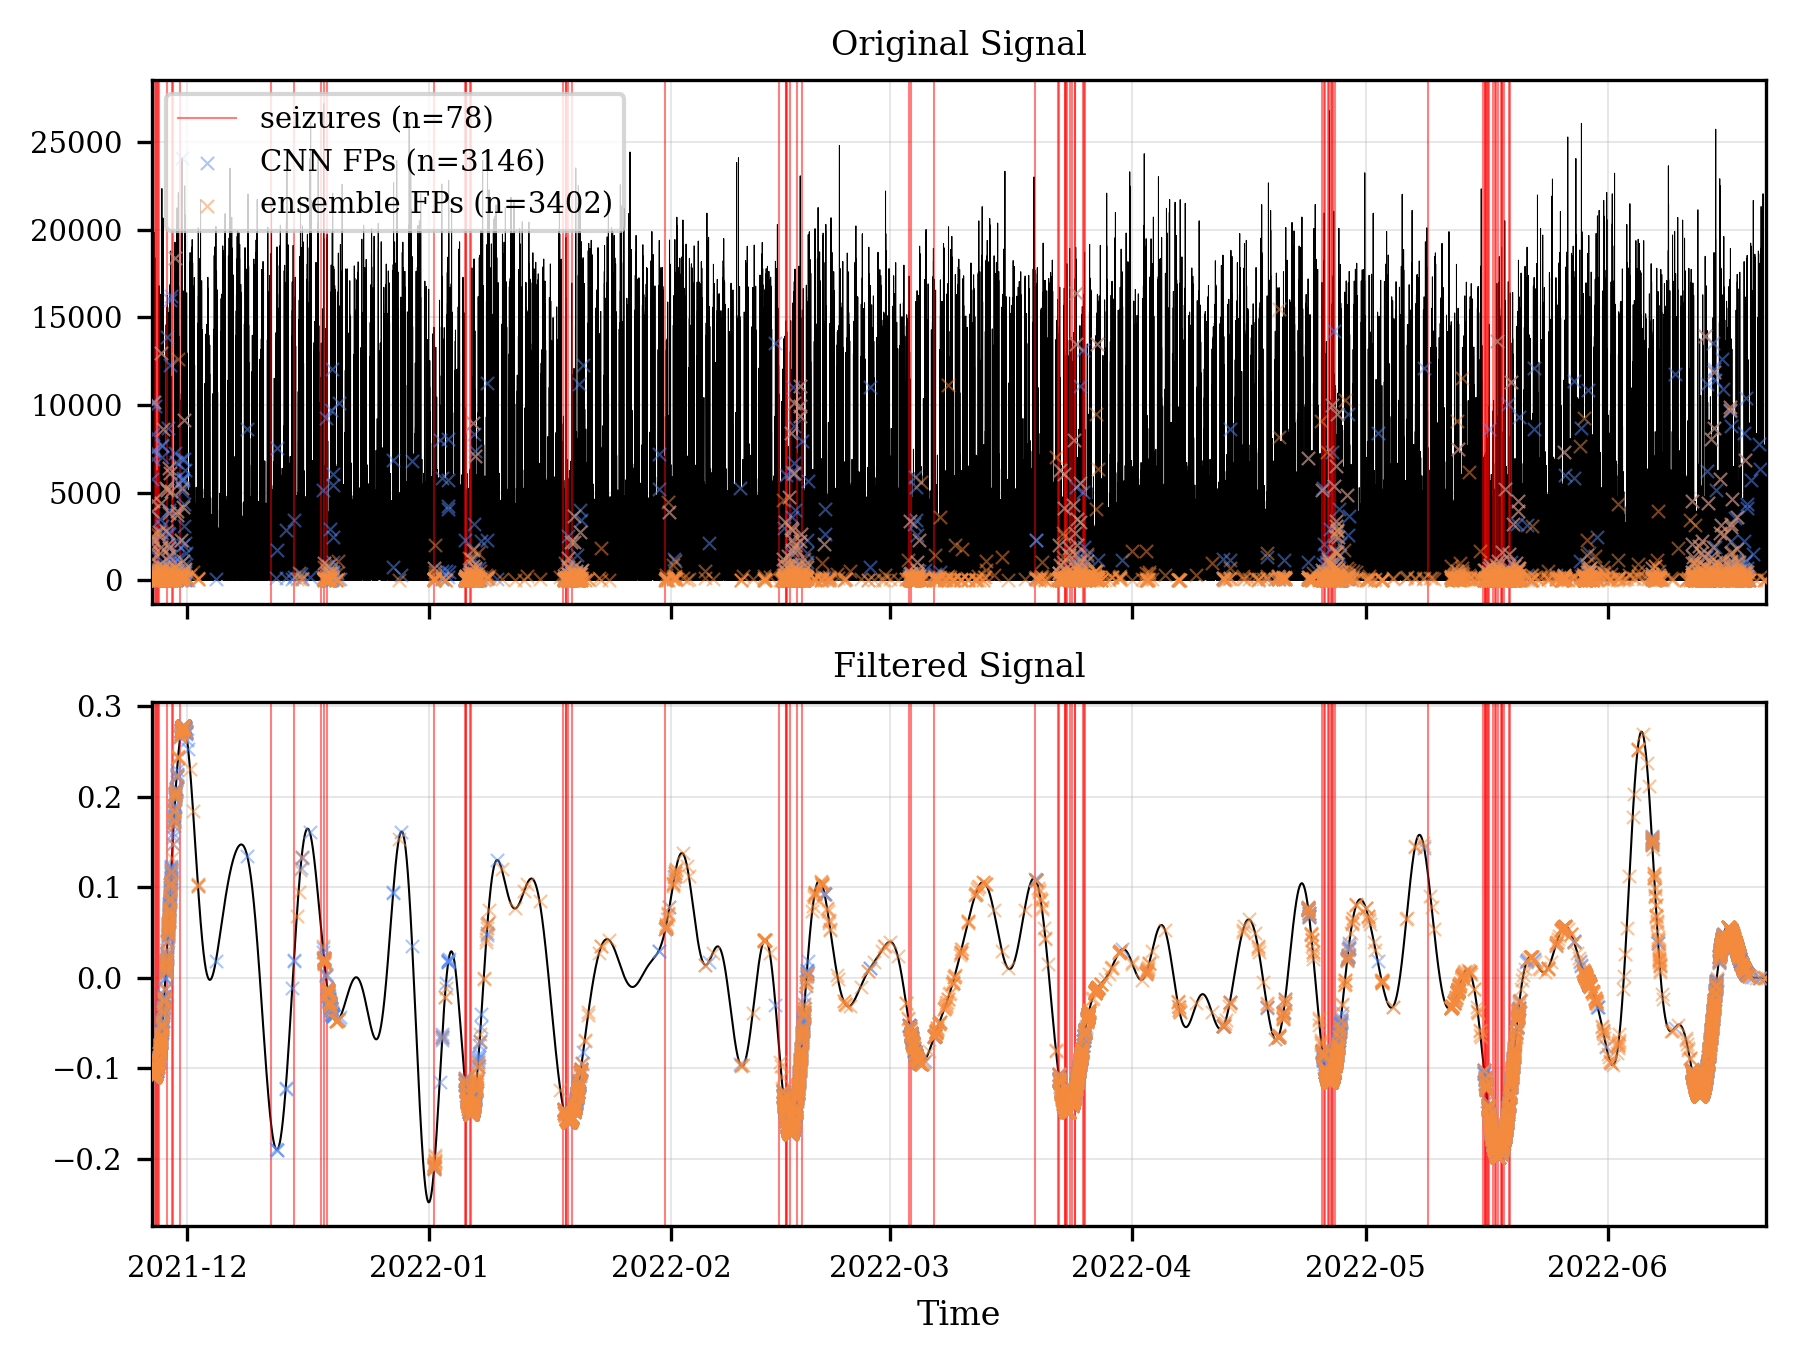

In [8]:
matplotlib_style.apply_style(use_small_font=True)

fig = plot_filtered_feature(
    original, filtered,
    samples_per_hour=Timedelta(hours=1) / SEGMENT.exact_dur,
    time=seg_starts,
    events=idxs_per_event_type,
    subplots_kwargs={'figsize': matplotlib_style.latex_figsize(height_ratio=0.75)},
)
for ax in fig.axes:
    ax.margins(x=0)
# fig.axes[0].set_ylabel(r'Voltage ($\mu$V)')
fig.tight_layout(pad=0, h_pad=1)
fig.show()

In [10]:
out_path = helpers.THESIS_FIGS_DIR / f'{rename_patient(pdir.name)}_filtered_{FEATURE}.pdf'
fig.savefig(out_path)